In [1]:
# Cell 1 — Imports and setup
import sys
import os
sys.path.insert(0, r"C:\Users\Ajant\Documents\OCT_EWS")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from src.data_manager import NpyLoader, filter_normal_predicted, get_embeddings_array
from src.reference_builder import ReferenceBuilder
from config.defaults import NORMAL_CLASS, DISEASE_CLASSES

print("Imports complete")

Imports complete


In [2]:
# Cell 2 — Load data and reference model
loader = NpyLoader(embeddings_root=r"C:\Users\Ajant\Documents\OCT_EWS\data\raw")
df_all = loader.load_all()

rb = ReferenceBuilder()
ref_model, metadata = rb.load(r"C:\Users\Ajant\Documents\OCT_EWS\data\processed")

print("Reference model ID:", metadata['reference_model_id'])

# Get test and train splits
df_test = df_all['test']
df_train = df_all['train']

# Get true normal training embeddings for reference
train_normal = df_train[df_train['true_label'] == NORMAL_CLASS]
X_train_normal = get_embeddings_array(train_normal)

# Get all test embeddings and labels
X_test = get_embeddings_array(df_test)
true_labels_test = df_test['true_label'].values

print(f"Training normal embeddings: {X_train_normal.shape}")
print(f"Test embeddings: {X_test.shape}")


  Loading all splits from .npy files
  Loading train split...
    Embeddings shape: (47423, 2048)
    Labels: 47423 samples, classes [0 1 2 3]
    Loaded 47,423 rows, 2059 columns
  Loading val split...
    Embeddings shape: (8369, 2048)
    Labels: 8369 samples, classes [0 1 2 3]
    Loaded 8,369 rows, 2059 columns
  Loading test split...
    Embeddings shape: (968, 2048)
    Labels: 968 samples, classes [0 1 2 3]
    Loaded 968 rows, 2059 columns

  Total rows loaded: 56,760

  Reference model loaded from: C:\Users\Ajant\Documents\OCT_EWS\data\processed
  Reference model ID: ref_2026_04_09_002400_standard_d2048_coreoff_pcaoff
  Created at: 2026-04-09T00:24:00.548670
  Mean shape : (2048,)
  Sigma shape: (2048, 2048)
Reference model ID: ref_2026_04_09_002400_standard_d2048_coreoff_pcaoff
Training normal embeddings: (19275, 2048)
Test embeddings: (968, 2048)


In [3]:
# Cell 3 — PCA dimensionality sweep

dimensions = [2048, 768, 256, 128, 64, 32]
DEFAULT_REGULARISATION = 1e-6

def mahalanobis_distances(X, mu, sigma_inv):
    diff = X - mu
    left = diff @ sigma_inv
    mahal_sq = np.sum(left * diff, axis=1)
    return np.sqrt(np.clip(mahal_sq, 0, None))

results = []

for n_dims in dimensions:
    if n_dims == 2048:
        # Full dimensionality — use existing reference model
        X_train_pca = X_train_normal
        X_test_pca = X_test
        mu = ref_model.mu
        sigma_inv = ref_model.sigma_inv
    else:
        # Apply PCA reduction
        pca = PCA(n_components=n_dims, random_state=42)
        X_train_pca = pca.fit_transform(X_train_normal)
        X_test_pca = pca.transform(X_test)
        explained = pca.explained_variance_ratio_.sum() * 100

        # Build new reference model in reduced space
        mu = X_train_pca.mean(axis=0)
        sigma = np.cov(X_train_pca, rowvar=False)
        sigma_reg = sigma + DEFAULT_REGULARISATION * np.eye(n_dims)
        sigma_inv = np.linalg.inv(sigma_reg)

        print(f"PCA-{n_dims}: explained variance = {explained:.4f}%")

    # Compute Mahalanobis on training normals for threshold
    mahal_train = mahalanobis_distances(X_train_pca, mu.reshape(1,-1), sigma_inv)
    thresh_90 = np.percentile(mahal_train, 90)

    # Compute on test set
    mahal_test = mahalanobis_distances(X_test_pca, mu.reshape(1,-1), sigma_inv)

    # Normal and disease separation
    normal_mask = true_labels_test == NORMAL_CLASS
    normal_scores = mahal_test[normal_mask]
    disease_scores = mahal_test[~normal_mask]

    results.append({
        'Dimensions': n_dims,
        'Mean (Normal)': round(normal_scores.mean(), 4),
        'Std (Normal)': round(normal_scores.std(), 4),
        '90th pct threshold': round(thresh_90, 4),
        'Mean (Disease)': round(disease_scores.mean(), 4),
        'Separation ratio': round(disease_scores.mean() / normal_scores.mean(), 4),
    })

df_pca = pd.DataFrame(results)
print("\n=== PCA Dimensionality Sweep Results ===")
print(df_pca.to_string(index=False))

PCA-768: explained variance = 100.0002%
PCA-256: explained variance = 100.0001%
PCA-128: explained variance = 99.9985%
PCA-64: explained variance = 99.9898%
PCA-32: explained variance = 99.9565%

=== PCA Dimensionality Sweep Results ===
 Dimensions  Mean (Normal)  Std (Normal)  90th pct threshold  Mean (Disease)  Separation ratio
       2048         9.4210        1.2726             12.5426         53.8490            5.7158
        768         9.4210        1.2726             12.5426         53.8490            5.7159
        256         9.4068        1.2694             12.5205         53.7821            5.7174
        128         8.8000        1.1842             11.7255         51.2962            5.8291
         64         7.0560        0.9898              9.4719         44.3104            6.2798
         32         5.0814        0.8366              7.0006         33.9371            6.6787


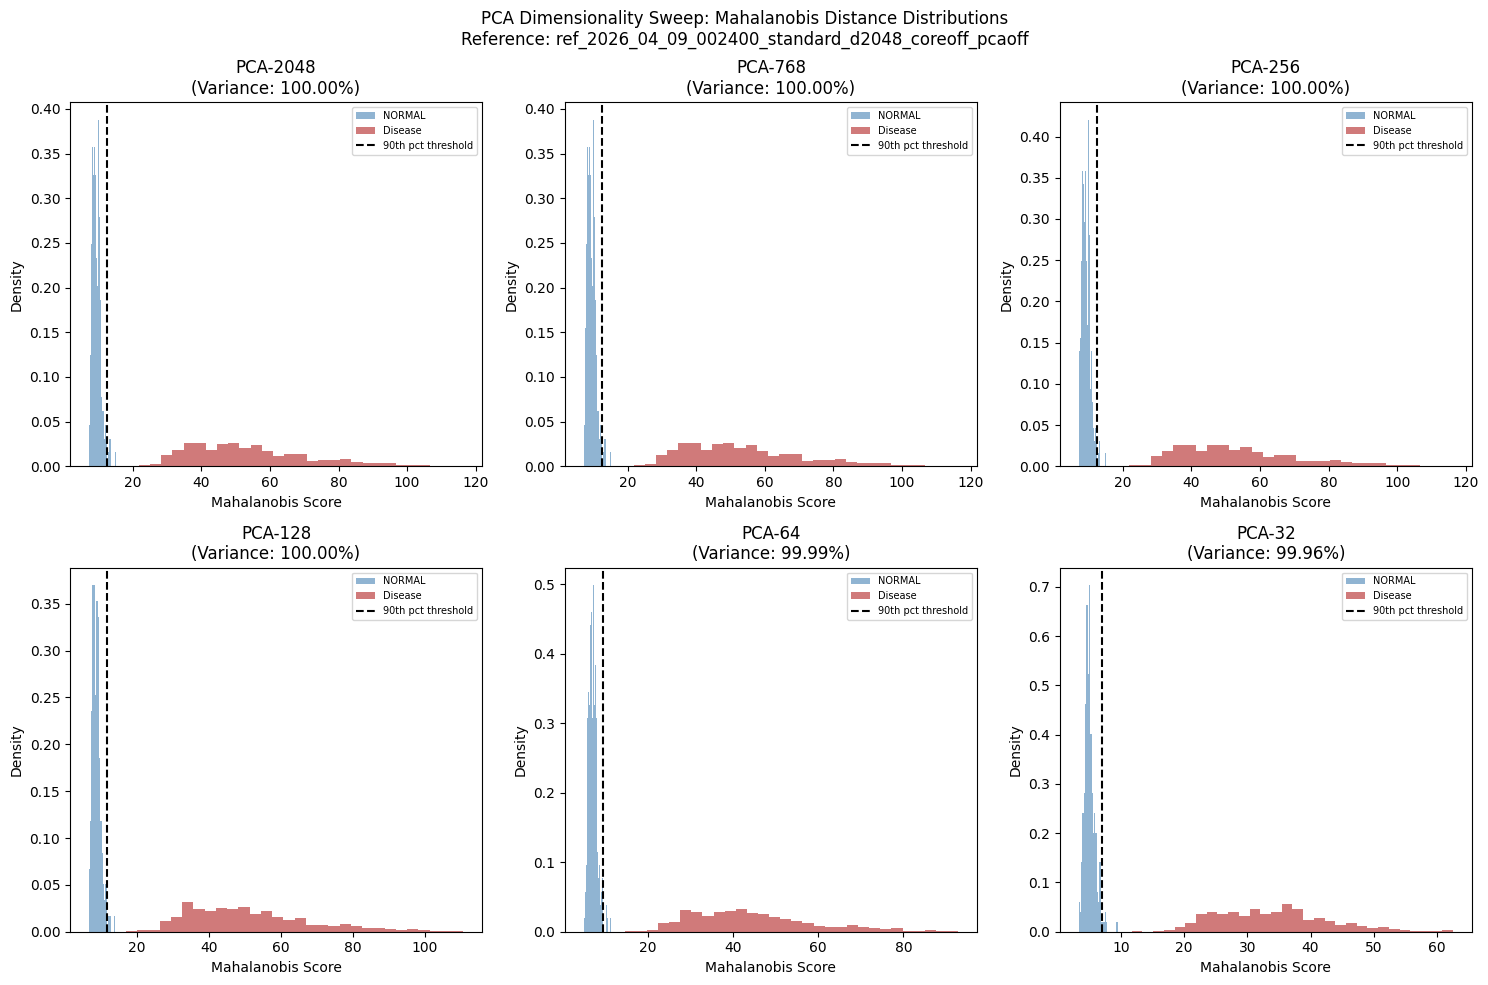

PCA sweep figure saved.


In [4]:
# Cell 4 — PCA sweep visualisation

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('PCA Dimensionality Sweep: Mahalanobis Distance Distributions\n'
             f'Reference: {metadata["reference_model_id"]}', fontsize=12)

axes_flat = axes.flatten()
DEFAULT_REGULARISATION = 1e-6

for idx, n_dims in enumerate(dimensions):
    ax = axes_flat[idx]

    if n_dims == 2048:
        X_train_pca = X_train_normal
        X_test_pca = X_test
        mu = ref_model.mu
        sigma_inv = ref_model.sigma_inv
        explained = 100.0
    else:
        pca = PCA(n_components=n_dims, random_state=42)
        X_train_pca = pca.fit_transform(X_train_normal)
        X_test_pca = pca.transform(X_test)
        explained = pca.explained_variance_ratio_.sum() * 100
        mu = X_train_pca.mean(axis=0)
        sigma = np.cov(X_train_pca, rowvar=False)
        sigma_reg = sigma + DEFAULT_REGULARISATION * np.eye(n_dims)
        sigma_inv = np.linalg.inv(sigma_reg)

    mahal_train = mahalanobis_distances(X_train_pca, mu.reshape(1,-1), sigma_inv)
    thresh_90 = np.percentile(mahal_train, 90)
    mahal_test = mahalanobis_distances(X_test_pca, mu.reshape(1,-1), sigma_inv)

    normal_mask = true_labels_test == NORMAL_CLASS

    ax.hist(mahal_test[normal_mask], bins=30, alpha=0.6,
            color='steelblue', label='NORMAL', density=True)
    ax.hist(mahal_test[~normal_mask], bins=30, alpha=0.6,
            color='firebrick', label='Disease', density=True)
    ax.axvline(thresh_90, color='black', linestyle='--',
               linewidth=1.5, label='90th pct threshold')
    ax.set_title(f'PCA-{n_dims}\n(Variance: {explained:.2f}%)')
    ax.set_xlabel('Mahalanobis Score')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(
    r'C:\Users\Ajant\Documents\OCT_EWS\data\outputs\pca_dimensionality_sweep.png',
    dpi=150, bbox_inches='tight')
plt.show()
print("PCA sweep figure saved.")

In [5]:
# Cell 5 — Save results and complete notebook

df_pca.to_csv(
    r'C:\Users\Ajant\Documents\OCT_EWS\data\outputs\pca_sweep_results.csv',
    index=False
)

print("=== NOTEBOOK 04 COMPLETE ===")
print("\nOutputs saved:")
print("  pca_dimensionality_sweep.png")
print("  pca_sweep_results.csv")
print(f"\nReference model: {metadata['reference_model_id']}")
print(f"Training normal cases: {len(X_train_normal)}")
print(f"Test cases: {len(X_test)}")
print(f"\nKey finding: Mahalanobis separation preserved from 2048D down to 32D")
print(f"Separation ratio improves from {df_pca.iloc[0]['Separation ratio']} "
      f"at 2048D to {df_pca.iloc[-1]['Separation ratio']} at 32D")

=== NOTEBOOK 04 COMPLETE ===

Outputs saved:
  pca_dimensionality_sweep.png
  pca_sweep_results.csv

Reference model: ref_2026_04_09_002400_standard_d2048_coreoff_pcaoff
Training normal cases: 19275
Test cases: 968

Key finding: Mahalanobis separation preserved from 2048D down to 32D
Separation ratio improves from 5.7158 at 2048D to 6.6787 at 32D
